# Grid Search Multi-Modelo: Hernia Hiatal en RX Frontal

Este notebook extiende la lógica de los notebooks de entrenamiento individuales para ejecutar una **búsqueda en grilla** sobre:

- `resnet18`
- `densenet121`
- `efficientnetb0`

Cada combinación de hiperparámetros se registra como un run independiente en **MLflow**.

<a id="etapa-1"></a>
## Etapa 1: Configuración y entorno

In [ ]:
# Etapa 1) Configuración clara y mínima
import random
import json
import sys
import socket
import subprocess
import time
from dataclasses import dataclass
from datetime import datetime
from itertools import product
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as T
from torch import nn
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision.models import (
    resnet18, ResNet18_Weights,
    densenet121, DenseNet121_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
)

from PIL import Image, ImageOps

import mlflow

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, f1_score

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('mlflow:', mlflow.__version__)

RAIZ = Path.cwd().resolve()
if RAIZ.name == 'jupyter':
    RAIZ = RAIZ.parent

# Soporta ejecución desde la raíz del curso o desde la raíz del microproyecto.
if not (RAIZ / 'data' / 'images').exists() and (RAIZ / 'Micro-proyecto' / 'maia_proyecto_desarrollo_soluciones').exists():
    RAIZ = RAIZ / 'Micro-proyecto' / 'maia_proyecto_desarrollo_soluciones'

RUTA_IMAGENES = RAIZ / 'data' / 'images'
RUTA_SALIDA = RAIZ / 'outputs' / 'hiatal_grid_search'
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

SEMILLA = 42
TAM_IMAGEN = 224
TAM_BATCH = 8
N_SPLITS = 2
PACIENCIA = 3
USAR_PREENTRENADO = False
USAR_ROI = True
USAR_AUTOCONTRASTE = True
USAR_AUMENTACION_TRAIN = True
FACTOR_MUESTRAS_ENTRENAMIENTO_POR_EPOCA = 1

# Modo rápido para ejecutar en notebook sin esperar horas.
MODO_RAPIDO = False

# Grid de hiperparámetros (cada combinación = 1 prueba MLflow).
ARQUITECTURAS = ['resnet18', 'densenet121', 'efficientnetb0']
GRID_LR = [3e-4, 1e-4, 1e-5] if MODO_RAPIDO else [1e-3, 3e-4, 1e-4, 5e-5]
GRID_DROPOUT = [0.25] if MODO_RAPIDO else [0.2, 0.3, 0.4]
GRID_WEIGHT_DECAY = [1e-3, 1e-4]
GRID_EPOCAS = [1] if MODO_RAPIDO else [6]
GRID_EPOCAS_CONGELADAS = [0] if MODO_RAPIDO else [2]

# MLflow solo en modo servidor (como los otros notebooks).
USAR_MLFLOW = True
MLFLOW_TRACKING_URI = 'http://localhost:8050'
MLFLOW_EXPERIMENTO = 'hernia-hiatal-grid-search'
PREFIJO_RUN = f"grid_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

# Autoarranque de servidor MLflow local (igual que notebooks anteriores).
MLFLOW_AUTO_INICIAR_SERVIDOR_LOCAL = True
MLFLOW_TIMEOUT_CONEXION_SEGUNDOS = 1.5
MLFLOW_SERVIDOR_LOCAL_HOST = '127.0.0.1'
MLFLOW_SERVIDOR_LOCAL_PUERTO = 8050
MLFLOW_SERVIDOR_LOCAL_ALLOWED_HOSTS = f'localhost:{MLFLOW_SERVIDOR_LOCAL_PUERTO},127.0.0.1:{MLFLOW_SERVIDOR_LOCAL_PUERTO}'
MLFLOW_SERVIDOR_LOCAL_BACKEND_DB = RUTA_SALIDA / 'mlflow_server_backend.db'
MLFLOW_SERVIDOR_LOCAL_ARTIFACTS = RUTA_SALIDA / 'mlflow_server_artifacts'
MLFLOW_SERVIDOR_LOCAL_LOG = RUTA_SALIDA / 'mlflow_server_local.log'

DISPOSITIVO = torch.device('cuda') if torch.cuda.is_available() else (
    torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
)
USAR_AMP = DISPOSITIVO.type == 'cuda'

print('RAIZ:', RAIZ)
print('Datos:', RUTA_IMAGENES)
print('Salida:', RUTA_SALIDA)
print('Dispositivo:', DISPOSITIVO)
print('MLflow URI:', MLFLOW_TRACKING_URI)
print('MLflow experimento:', MLFLOW_EXPERIMENTO)
print('MODO_RAPIDO:', MODO_RAPIDO)


torch: 2.8.0
torchvision: 0.23.0
mlflow: 3.9.0
RAIZ: /Users/ra/Library/CloudStorage/GoogleDrive-ricardoaarango@gmail.com/My Drive/Educacion/U de los Andes/MAIA/IV/Proyecto - Desarrollo de Soluciones/Micro-proyecto/maia_proyecto_desarrollo_soluciones
Datos: /Users/ra/Library/CloudStorage/GoogleDrive-ricardoaarango@gmail.com/My Drive/Educacion/U de los Andes/MAIA/IV/Proyecto - Desarrollo de Soluciones/Micro-proyecto/maia_proyecto_desarrollo_soluciones/data/images
Salida: /Users/ra/Library/CloudStorage/GoogleDrive-ricardoaarango@gmail.com/My Drive/Educacion/U de los Andes/MAIA/IV/Proyecto - Desarrollo de Soluciones/Micro-proyecto/maia_proyecto_desarrollo_soluciones/outputs/hiatal_grid_search
Dispositivo: mps
MLflow URI: http://localhost:8050
MLflow experimento: hernia-hiatal-grid-search
MODO_RAPIDO: True


<a id="etapa-2"></a>
## Etapa 2: Utilidades de datos, modelo, entrenamiento y MLflow

In [7]:
# Etapa 2) Utilidades del pipeline
EXTENSIONES_VALIDAS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}
ETIQUETAS_NORMAL = {'0', 'normal', 'sano', 'healthy', 'neg', 'negative'}
MEDIA_IMAGENET = [0.485, 0.456, 0.406]
STD_IMAGENET = [0.229, 0.224, 0.225]


def fijar_semilla(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


fijar_semilla(SEMILLA)


@dataclass(frozen=True)
class Muestra:
    ruta: Path
    etiqueta: int
    id_paciente: str


class RecorteRetrocardiaco:
    def __init__(self, x1=0.2, x2=0.8, y1=0.15, y2=0.98):
        self.x1, self.x2, self.y1, self.y2 = x1, x2, y1, y2

    def __call__(self, imagen: Image.Image):
        ancho, alto = imagen.size
        return imagen.crop((int(self.x1 * ancho), int(self.y1 * alto), int(self.x2 * ancho), int(self.y2 * alto)))


class ConjuntoHiatal(Dataset):
    def __init__(self, muestras, indices, transformacion):
        self.muestras = [muestras[i] for i in indices]
        self.transformacion = transformacion

    def __len__(self):
        return len(self.muestras)

    def __getitem__(self, i):
        muestra = self.muestras[i]
        with Image.open(muestra.ruta) as imagen:
            imagen_gris = imagen.convert('L')

        if USAR_AUTOCONTRASTE:
            imagen_gris = ImageOps.autocontrast(imagen_gris)

        imagen_rgb = Image.merge('RGB', (imagen_gris, imagen_gris, imagen_gris))
        tensor_entrada = self.transformacion(imagen_rgb)
        objetivo = torch.tensor(float(muestra.etiqueta), dtype=torch.float32)
        return tensor_entrada, objetivo, str(muestra.ruta)


def construir_muestras_desde_carpetas(ruta_imagenes: Path):
    pares = []
    for carpeta_clase in sorted([p for p in ruta_imagenes.iterdir() if p.is_dir()]):
        etiqueta = 0 if carpeta_clase.name.strip().lower() in ETIQUETAS_NORMAL else 1
        for ruta_imagen in sorted(carpeta_clase.rglob('*')):
            if ruta_imagen.suffix.lower() in EXTENSIONES_VALIDAS:
                pares.append((ruta_imagen, etiqueta))

    if not pares:
        raise RuntimeError(f'No se encontraron imágenes en {ruta_imagenes}')

    muestras = []
    for ruta_imagen, etiqueta in pares:
        id_paciente = ruta_imagen.stem.split('_')[0]
        muestras.append(Muestra(ruta=ruta_imagen, etiqueta=int(etiqueta), id_paciente=id_paciente))
    return muestras


def construir_transformaciones(tam_imagen=320, usar_roi=True, usar_aug_train=True):
    ops_roi = [RecorteRetrocardiaco()] if usar_roi else []
    normalizacion = T.Normalize(mean=MEDIA_IMAGENET, std=STD_IMAGENET)

    ops_aug = []
    if usar_aug_train:
        ops_aug = [
            T.RandomApply([T.ColorJitter(brightness=0.12, contrast=0.15)], p=0.35),
            T.RandomAffine(degrees=8, translate=(0.03, 0.03), scale=(0.97, 1.03)),
        ]

    transf_train = T.Compose(ops_roi + [T.Resize((tam_imagen, tam_imagen))] + ops_aug + [T.ToTensor(), normalizacion])
    transf_val = T.Compose(ops_roi + [T.Resize((tam_imagen, tam_imagen)), T.ToTensor(), normalizacion])
    return transf_train, transf_val


def crear_modelo(nombre_modelo: str, preentrenado=True, dropout=0.25):
    nombre_modelo = nombre_modelo.lower()

    if nombre_modelo == 'resnet18':
        pesos = ResNet18_Weights.DEFAULT if preentrenado else None
        modelo = resnet18(weights=pesos)
        in_features = modelo.fc.in_features
        modelo.fc = nn.Sequential(nn.Dropout(p=float(dropout)), nn.Linear(in_features, 1))
        return modelo

    if nombre_modelo == 'densenet121':
        pesos = DenseNet121_Weights.DEFAULT if preentrenado else None
        modelo = densenet121(weights=pesos)
        in_features = modelo.classifier.in_features
        modelo.classifier = nn.Sequential(nn.Dropout(p=float(dropout)), nn.Linear(in_features, 1))
        return modelo

    if nombre_modelo == 'efficientnetb0':
        pesos = EfficientNet_B0_Weights.DEFAULT if preentrenado else None
        modelo = efficientnet_b0(weights=pesos)
        in_features = modelo.classifier[1].in_features
        modelo.classifier = nn.Sequential(
            nn.Dropout(p=float(dropout), inplace=True),
            nn.Linear(in_features, 1),
        )
        return modelo

    raise ValueError(f'Modelo no soportado: {nombre_modelo}')


def fijar_backbone_entrenable(modelo, nombre_modelo: str, entrenable: bool):
    for p in modelo.parameters():
        p.requires_grad = entrenable

    nombre_modelo = nombre_modelo.lower()
    if nombre_modelo == 'resnet18':
        cabeza = modelo.fc.parameters()
    elif nombre_modelo == 'densenet121':
        cabeza = modelo.classifier.parameters()
    elif nombre_modelo == 'efficientnetb0':
        cabeza = modelo.classifier.parameters()
    else:
        cabeza = []

    for p in cabeza:
        p.requires_grad = True


def calcular_peso_positivo(muestras, indices, dispositivo):
    etiquetas = np.array([muestras[i].etiqueta for i in indices], dtype=np.float32)
    positivos = float(etiquetas.sum())
    negativos = float(len(etiquetas) - positivos)
    return torch.tensor([negativos / max(positivos, 1.0)], device=dispositivo)


def crear_loader_entrenamiento(dataset_train, tam_batch, dispositivo, factor_muestras_epoca=1):
    pin_memory = dispositivo.type == 'cuda'
    if factor_muestras_epoca > 1:
        sampler = RandomSampler(
            dataset_train,
            replacement=True,
            num_samples=int(len(dataset_train) * factor_muestras_epoca),
        )
        return DataLoader(dataset_train, batch_size=tam_batch, shuffle=False, sampler=sampler, num_workers=0, pin_memory=pin_memory)
    return DataLoader(dataset_train, batch_size=tam_batch, shuffle=True, num_workers=0, pin_memory=pin_memory)


def ejecutar_epoca(modelo, loader, criterio, dispositivo, optimizador=None, escalador_amp=None):
    es_train = optimizador is not None
    modelo.train() if es_train else modelo.eval()

    perdidas, y_all, p_all = [], [], []
    non_blocking = dispositivo.type == 'cuda'
    usar_autocast = (escalador_amp is not None) and (dispositivo.type == 'cuda')

    for entradas, objetivos, _ in loader:
        entradas = entradas.to(dispositivo, non_blocking=non_blocking)
        objetivos = objetivos.to(dispositivo, non_blocking=non_blocking).unsqueeze(1)

        with torch.set_grad_enabled(es_train):
            if usar_autocast:
                with torch.amp.autocast(device_type='cuda', enabled=True):
                    logits = modelo(entradas)
                    perdida = criterio(logits, objetivos)
            else:
                logits = modelo(entradas)
                perdida = criterio(logits, objetivos)

            probabilidades = torch.sigmoid(logits)

            if es_train:
                optimizador.zero_grad(set_to_none=True)
                if usar_autocast:
                    escalador_amp.scale(perdida).backward()
                    escalador_amp.step(optimizador)
                    escalador_amp.update()
                else:
                    perdida.backward()
                    optimizador.step()

        perdidas.append(perdida.detach().item() * entradas.size(0))
        y_all.append(objetivos.detach().cpu().numpy().reshape(-1))
        p_all.append(probabilidades.detach().cpu().numpy().reshape(-1))

    y_ep = np.concatenate(y_all)
    p_ep = np.concatenate(p_all)
    loss_ep = float(np.sum(perdidas) / len(loader.dataset))
    return loss_ep, y_ep, p_ep


@torch.no_grad()
def predecir_loader(modelo, loader, dispositivo):
    modelo.eval()
    y_all, p_all = [], []
    non_blocking = dispositivo.type == 'cuda'

    for entradas, objetivos, _ in loader:
        entradas = entradas.to(dispositivo, non_blocking=non_blocking)
        logits = modelo(entradas)
        probs = torch.sigmoid(logits)
        y_all.extend([int(round(float(v))) for v in objetivos.numpy().tolist()])
        p_all.extend(probs.squeeze(1).detach().cpu().numpy().astype(float).tolist())

    return np.asarray(y_all, dtype=int), np.asarray(p_all, dtype=float)


def buscar_umbral_optimo(y_real, p_pred):
    y_real = np.rint(np.asarray(y_real).reshape(-1)).astype(int)
    p_pred = np.clip(np.asarray(p_pred).reshape(-1).astype(float), 0.0, 1.0)
    if len(np.unique(y_real)) < 2:
        return 0.5

    umbrales = np.unique(p_pred)
    mejor_thr, mejor_j = 0.5, -np.inf
    for thr in umbrales:
        yb = (p_pred >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_real, yb, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        esp = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        j = sens + esp - 1.0
        if j > mejor_j:
            mejor_j = j
            mejor_thr = float(thr)
    return mejor_thr


def calcular_metricas(y_real, p_pred, umbral=0.5):
    y_real = np.rint(np.asarray(y_real).reshape(-1)).astype(int)
    p_pred = np.clip(np.asarray(p_pred).reshape(-1).astype(float), 0.0, 1.0)
    y_bin = (p_pred >= umbral).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_real, y_bin, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    esp = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    auc_val = float(roc_auc_score(y_real, p_pred)) if len(np.unique(y_real)) > 1 else np.nan

    return {
        'umbral': float(umbral),
        'auc': auc_val,
        'accuracy': float(accuracy_score(y_real, y_bin)),
        'f1': float(f1_score(y_real, y_bin, zero_division=0)),
        'sensibilidad': float(sens) if np.isfinite(sens) else np.nan,
        'especificidad': float(esp) if np.isfinite(esp) else np.nan,
        'tp': int(tp),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
    }


def mlflow_log_metricas(metricas: dict, prefijo='', step=None):
    if mlflow.active_run() is None:
        return
    for k, v in metricas.items():
        if not isinstance(v, (int, float, np.integer, np.floating)):
            continue
        valor = float(v)
        if not np.isfinite(valor):
            continue
        nombre = f'{prefijo}.{k}' if prefijo else str(k)
        if step is None:
            mlflow.log_metric(nombre, valor)
        else:
            mlflow.log_metric(nombre, valor, step=int(step))


# ------- Autoarranque MLflow servidor local -------
MLFLOW_PROCESO_SERVIDOR_LOCAL = None


def mlflow_tracking_disponible(uri=None, timeout_s=None):
    uri = (uri or MLFLOW_TRACKING_URI).strip()
    timeout_s = float(timeout_s or MLFLOW_TIMEOUT_CONEXION_SEGUNDOS)
    parsed = urlparse(uri)

    if parsed.scheme in {'', 'file'}:
        return True

    if parsed.scheme in {'http', 'https'} and parsed.hostname:
        port = parsed.port or (443 if parsed.scheme == 'https' else 80)
        try:
            with socket.create_connection((parsed.hostname, port), timeout=timeout_s):
                return True
        except OSError:
            return False

    return True


def mlflow_iniciar_servidor_local_si_falta():
    global MLFLOW_PROCESO_SERVIDOR_LOCAL

    if (not USAR_MLFLOW) or (not MLFLOW_AUTO_INICIAR_SERVIDOR_LOCAL):
        return

    parsed = urlparse(MLFLOW_TRACKING_URI)
    host = parsed.hostname or ''
    if host not in {'localhost', '127.0.0.1'}:
        return

    if mlflow_tracking_disponible():
        return

    if (MLFLOW_PROCESO_SERVIDOR_LOCAL is not None) and (MLFLOW_PROCESO_SERVIDOR_LOCAL.poll() is None):
        return

    MLFLOW_SERVIDOR_LOCAL_ARTIFACTS.mkdir(parents=True, exist_ok=True)

    cmd = [
        sys.executable, '-m', 'mlflow', 'server',
        '--host', MLFLOW_SERVIDOR_LOCAL_HOST,
        '--port', str(MLFLOW_SERVIDOR_LOCAL_PUERTO),
        '--workers', '1',
        '--backend-store-uri', f"sqlite:///{MLFLOW_SERVIDOR_LOCAL_BACKEND_DB.resolve()}",
        '--default-artifact-root', MLFLOW_SERVIDOR_LOCAL_ARTIFACTS.resolve().as_uri(),
        '--allowed-hosts', MLFLOW_SERVIDOR_LOCAL_ALLOWED_HOSTS,
    ]

    with open(MLFLOW_SERVIDOR_LOCAL_LOG, 'a', encoding='utf-8') as logf:
        MLFLOW_PROCESO_SERVIDOR_LOCAL = subprocess.Popen(cmd, stdout=logf, stderr=logf, cwd=str(RAIZ))

    for _ in range(30):
        time.sleep(0.5)
        if mlflow_tracking_disponible():
            print(f'MLflow local activo en {MLFLOW_TRACKING_URI}')
            return

    raise RuntimeError(
        f'No se pudo iniciar MLflow en {MLFLOW_TRACKING_URI}. '
        f'Revisa logs en {MLFLOW_SERVIDOR_LOCAL_LOG}'
    )


<a id="etapa-3"></a>
## Etapa 3: Cargar datos y definir folds

In [8]:
# Etapa 3) Carga de datos
muestras = construir_muestras_desde_carpetas(RUTA_IMAGENES)
y_global = np.array([m.etiqueta for m in muestras], dtype=int)

print('Total muestras:', len(muestras))
print('Normales:', int((y_global == 0).sum()))
print('Hernia:', int((y_global == 1).sum()))

indices = np.arange(len(muestras))
pliegues_cv = list(StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEMILLA).split(indices, y_global))
print('N folds:', len(pliegues_cv))


Total muestras: 70
Normales: 25
Hernia: 45
N folds: 2


<a id="etapa-4"></a>
## Etapa 4: Construir grilla de experimentos

In [9]:
# Etapa 4) Grid de combinaciones
combinaciones = []
for (arquitectura, lr, dropout, wd, epocas, epocas_congeladas) in product(
    ARQUITECTURAS,
    GRID_LR,
    GRID_DROPOUT,
    GRID_WEIGHT_DECAY,
    GRID_EPOCAS,
    GRID_EPOCAS_CONGELADAS,
):
    combinaciones.append({
        'arquitectura': arquitectura,
        'lr': float(lr),
        'dropout': float(dropout),
        'weight_decay': float(wd),
        'epocas': int(epocas),
        'epocas_congeladas': int(epocas_congeladas),
    })

df_grid = pd.DataFrame(combinaciones)
print('Total pruebas grid:', len(df_grid))
print(df_grid.head(20).to_string(index=False))


Total pruebas grid: 6
  arquitectura     lr  dropout  weight_decay  epocas  epocas_congeladas
      resnet18 0.0003     0.25        0.0001       1                  0
      resnet18 0.0001     0.25        0.0001       1                  0
   densenet121 0.0003     0.25        0.0001       1                  0
   densenet121 0.0001     0.25        0.0001       1                  0
efficientnetb0 0.0003     0.25        0.0001       1                  0
efficientnetb0 0.0001     0.25        0.0001       1                  0


<a id="etapa-5"></a>
## Etapa 5: Ejecutar grid search con validación cruzada y MLflow

In [10]:
# Etapa 5) Ejecución del grid
if USAR_MLFLOW:
    mlflow_iniciar_servidor_local_si_falta()
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(MLFLOW_EXPERIMENTO)

resultados = []
ruta_resultados = RUTA_SALIDA / 'grid_results.csv'

for i, cfg in enumerate(combinaciones, start=1):
    nombre_trial = (
        f"{PREFIJO_RUN}_trial{i:03d}_"
        f"{cfg['arquitectura']}_lr{cfg['lr']}_do{cfg['dropout']}_wd{cfg['weight_decay']}_e{cfg['epocas']}"
    )
    print() 
    print('=' * 100)
    print(f"Trial {i}/{len(combinaciones)} -> {nombre_trial}")

    if USAR_MLFLOW:
        mlflow.start_run(run_name=nombre_trial)
    try:
        if USAR_MLFLOW:
            for k, v in cfg.items():
                mlflow.log_param(k, v)
            mlflow.log_param('tam_imagen', TAM_IMAGEN)
            mlflow.log_param('tam_batch', TAM_BATCH)
            mlflow.log_param('n_splits', N_SPLITS)
            mlflow.log_param('usar_preentrenado', USAR_PREENTRENADO)
            mlflow.log_param('usar_roi', USAR_ROI)
            mlflow.log_param('usar_autocontraste', USAR_AUTOCONTRASTE)
            mlflow.log_param('usar_aug_train', USAR_AUMENTACION_TRAIN)
            mlflow.log_param('factor_muestras_epoca', FACTOR_MUESTRAS_ENTRENAMIENTO_POR_EPOCA)
            mlflow.set_tag('pipeline', 'grid_search_cv')

        metricas_folds = []

        for id_fold, (idx_train, idx_val) in enumerate(pliegues_cv, start=1):
            fijar_semilla(SEMILLA + id_fold)

            transf_train, transf_val = construir_transformaciones(
                tam_imagen=TAM_IMAGEN,
                usar_roi=USAR_ROI,
                usar_aug_train=USAR_AUMENTACION_TRAIN,
            )

            ds_train = ConjuntoHiatal(muestras, idx_train, transf_train)
            ds_val = ConjuntoHiatal(muestras, idx_val, transf_val)

            loader_train = crear_loader_entrenamiento(
                ds_train,
                tam_batch=TAM_BATCH,
                dispositivo=DISPOSITIVO,
                factor_muestras_epoca=FACTOR_MUESTRAS_ENTRENAMIENTO_POR_EPOCA,
            )
            loader_val = DataLoader(
                ds_val,
                batch_size=TAM_BATCH,
                shuffle=False,
                num_workers=0,
                pin_memory=(DISPOSITIVO.type == 'cuda'),
            )

            modelo = crear_modelo(
                cfg['arquitectura'],
                preentrenado=USAR_PREENTRENADO,
                dropout=cfg['dropout'],
            ).to(DISPOSITIVO)

            if cfg['epocas_congeladas'] > 0:
                fijar_backbone_entrenable(modelo, cfg['arquitectura'], False)

            optimizador = torch.optim.AdamW(modelo.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=max(1, cfg['epocas']))
            peso_pos = calcular_peso_positivo(muestras, idx_train, DISPOSITIVO)
            criterio = nn.BCEWithLogitsLoss(pos_weight=peso_pos)
            escalador = torch.amp.GradScaler('cuda', enabled=USAR_AMP)

            mejor = None
            sin_mejora = 0

            for epoca in range(1, cfg['epocas'] + 1):
                if cfg['epocas_congeladas'] > 0 and epoca == cfg['epocas_congeladas'] + 1:
                    fijar_backbone_entrenable(modelo, cfg['arquitectura'], True)

                loss_train, _, _ = ejecutar_epoca(modelo, loader_train, criterio, DISPOSITIVO, optimizador=optimizador, escalador_amp=escalador)
                loss_val, _, _ = ejecutar_epoca(modelo, loader_val, criterio, DISPOSITIVO, optimizador=None, escalador_amp=None)

                y_val, p_val = predecir_loader(modelo, loader_val, DISPOSITIVO)
                thr = buscar_umbral_optimo(y_val, p_val)
                met = calcular_metricas(y_val, p_val, umbral=thr)
                score = met['auc'] if np.isfinite(met['auc']) else met['f1']

                if USAR_MLFLOW:
                    mlflow_log_metricas({
                        'loss_train': loss_train,
                        'loss_val': loss_val,
                        'auc': met['auc'],
                        'f1': met['f1'],
                        'accuracy': met['accuracy'],
                        'sensibilidad': met['sensibilidad'],
                        'especificidad': met['especificidad'],
                        'umbral': met['umbral'],
                        'score': score,
                    }, prefijo=f'fold_{id_fold}.epoch', step=epoca)

                if (mejor is None) or (score > mejor['score']):
                    mejor = {
                        'score': float(score),
                        'umbral': float(thr),
                        'state_dict': {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()},
                    }
                    sin_mejora = 0
                else:
                    sin_mejora += 1

                scheduler.step()
                if sin_mejora >= PACIENCIA:
                    break

            modelo.load_state_dict(mejor['state_dict'])
            y_val, p_val = predecir_loader(modelo, loader_val, DISPOSITIVO)
            met_fold = calcular_metricas(y_val, p_val, umbral=mejor['umbral'])
            met_fold['fold'] = id_fold
            metricas_folds.append(met_fold)

            if USAR_MLFLOW:
                mlflow_log_metricas(met_fold, prefijo=f'fold_{id_fold}.final', step=id_fold)

            print(
                f"  Fold {id_fold}: auc={met_fold['auc']:.4f} "
                f"acc={met_fold['accuracy']:.4f} f1={met_fold['f1']:.4f} "
                f"sens={met_fold['sensibilidad']:.4f} esp={met_fold['especificidad']:.4f}"
            )

        resumen = {}
        for m in ['auc', 'accuracy', 'f1', 'sensibilidad', 'especificidad']:
            vals = [float(x[m]) for x in metricas_folds]
            resumen[f'{m}_mean'] = float(np.nanmean(vals))
            resumen[f'{m}_std'] = float(np.nanstd(vals))

        if USAR_MLFLOW:
            mlflow_log_metricas(resumen, prefijo='cv.summary')

        fila = dict(cfg)
        fila.update(resumen)
        fila['trial_name'] = nombre_trial
        resultados.append(fila)

    finally:
        if USAR_MLFLOW and (mlflow.active_run() is not None):
            mlflow.end_run()

# Guardamos leaderboard consolidado.
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(['auc_mean', 'f1_mean'], ascending=False).reset_index(drop=True)
df_resultados.to_csv(ruta_resultados, index=False)

print() 
print('Grid finalizado. Leaderboard top:')
print(df_resultados.head(20).to_string(index=False))
print('Resultados guardados en:', ruta_resultados)


2026/02/22 17:34:32 INFO mlflow.tracking.fluent: Experiment with name 'hernia-hiatal-grid-search' does not exist. Creating a new experiment.


MLflow local activo en http://localhost:8050

Trial 1/6 -> grid_20260222_173427_trial001_resnet18_lr0.0003_do0.25_wd0.0001_e1
  Fold 1: auc=0.4275 acc=0.6857 f1=0.8070 sens=1.0000 esp=0.0833
  Fold 2: auc=0.5210 acc=0.6000 f1=0.6667 sens=0.6364 esp=0.5385
🏃 View run grid_20260222_173427_trial001_resnet18_lr0.0003_do0.25_wd0.0001_e1 at: http://localhost:8050/#/experiments/1/runs/4a0ecb3a3e574c88b9449256940b6d18
🧪 View experiment at: http://localhost:8050/#/experiments/1

Trial 2/6 -> grid_20260222_173427_trial002_resnet18_lr0.0001_do0.25_wd0.0001_e1
  Fold 1: auc=0.4167 acc=0.7143 f1=0.8214 sens=1.0000 esp=0.1667
  Fold 2: auc=0.6224 acc=0.6857 f1=0.7027 sens=0.5909 esp=0.8462
🏃 View run grid_20260222_173427_trial002_resnet18_lr0.0001_do0.25_wd0.0001_e1 at: http://localhost:8050/#/experiments/1/runs/86b27e6919f8468bb703f80804bdbd44
🧪 View experiment at: http://localhost:8050/#/experiments/1

Trial 3/6 -> grid_20260222_173427_trial003_densenet121_lr0.0003_do0.25_wd0.0001_e1
  Fold 1: auc

<a id="etapa-6"></a>
## Etapa 6: Reporte final y artefactos

In [11]:
# Etapa 6) Resumen final
if 'df_resultados' in globals() and len(df_resultados) > 0:
    mejor = df_resultados.iloc[0].to_dict()
    resumen_json = {
        'fecha': datetime.now().isoformat(),
        'n_trials': int(len(df_resultados)),
        'mejor_trial': mejor,
        'mlflow_tracking_uri': MLFLOW_TRACKING_URI,
        'mlflow_experimento': MLFLOW_EXPERIMENTO,
        'modo_rapido': bool(MODO_RAPIDO),
        'n_splits': int(N_SPLITS),
    }

    ruta_resumen = RUTA_SALIDA / 'grid_summary.json'
    ruta_resumen.write_text(json.dumps(resumen_json, indent=2), encoding='utf-8')

    print('Mejor trial:')
    print(json.dumps(mejor, indent=2, ensure_ascii=False))
    print('Resumen JSON:', ruta_resumen)
    print('MLflow en modo servidor. Abre: http://localhost:8050/#/experiments')
else:
    print('No hay resultados de grid para resumir.')


Mejor trial:
{
  "arquitectura": "resnet18",
  "lr": 0.0001,
  "dropout": 0.25,
  "weight_decay": 0.0001,
  "epocas": 1,
  "epocas_congeladas": 0,
  "auc_mean": 0.5195221445221445,
  "auc_std": 0.10285547785547788,
  "accuracy_mean": 0.7,
  "accuracy_std": 0.01428571428571429,
  "f1_mean": 0.7620656370656371,
  "f1_std": 0.05936293436293433,
  "sensibilidad_mean": 0.7954545454545454,
  "sensibilidad_std": 0.20454545454545453,
  "especificidad_mean": 0.5064102564102564,
  "especificidad_std": 0.33974358974358976,
  "trial_name": "grid_20260222_173427_trial002_resnet18_lr0.0001_do0.25_wd0.0001_e1"
}
Resumen JSON: /Users/ra/Library/CloudStorage/GoogleDrive-ricardoaarango@gmail.com/My Drive/Educacion/U de los Andes/MAIA/IV/Proyecto - Desarrollo de Soluciones/Micro-proyecto/maia_proyecto_desarrollo_soluciones/outputs/hiatal_grid_search/grid_summary.json
MLflow en modo servidor. Abre: http://localhost:8050/#/experiments


<a id="etapa-7"></a>
## Etapa 7: Comparación visual dentro del notebook

Lee el leaderboard consolidado desde MLflow y muestra la comparación por arquitectura/hiperparámetros.

Leaderboard (top 15):
                                                                run_name   arquitectura     lr  epocas  auc_mean  f1_mean  accuracy_mean
   grid_20260222_164850_trial003_densenet121_lr0.0003_do0.25_wd0.0001_e2    densenet121 0.0003       2  0.842315 0.863636       0.828571
      grid_20260222_164850_trial001_resnet18_lr0.0003_do0.25_wd0.0001_e2       resnet18 0.0003       2  0.773057 0.880000       0.828571
   grid_20260222_164850_trial004_densenet121_lr0.0001_do0.25_wd0.0001_e2    densenet121 0.0001       2  0.759235 0.857500       0.800000
      grid_20260222_164850_trial002_resnet18_lr0.0001_do0.25_wd0.0001_e2       resnet18 0.0001       2  0.676877 0.799468       0.728571
      grid_20260222_165216_trial001_resnet18_lr0.0003_do0.25_wd0.0001_e1       resnet18 0.0003       1  0.506423 0.767145       0.671429
grid_20260222_165216_trial005_efficientnetb0_lr0.0003_do0.25_wd0.0001_e1 efficientnetb0 0.0003       1  0.500000 0.782517       0.642857
      grid_20260222

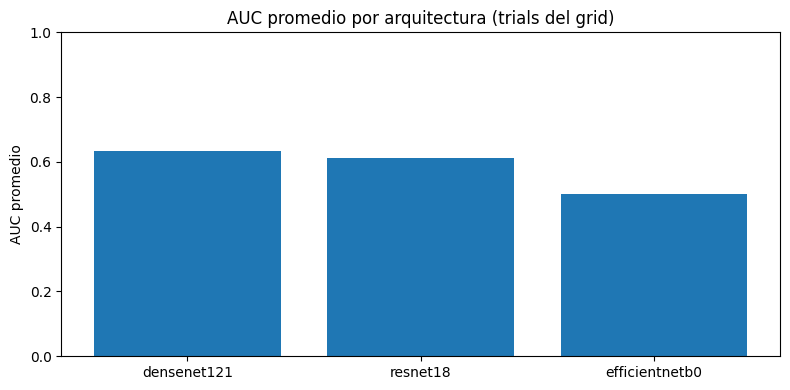


MLflow backend usado por este notebook:
http://localhost:8050
Este notebook registra en servidor MLflow. Abre: http://localhost:8050/#/experiments


In [12]:
# Etapa 7) Comparación en notebook
ruta_leaderboard = RUTA_SALIDA / 'leaderboard_from_mlflow.csv'
if not ruta_leaderboard.exists():
    print('No existe leaderboard_from_mlflow.csv todavía. Ejecuta primero el grid completo.')
else:
    df_lb = pd.read_csv(ruta_leaderboard)
    print('Leaderboard (top 15):')
    cols = ['run_name', 'arquitectura', 'lr', 'epocas', 'auc_mean', 'f1_mean', 'accuracy_mean']
    cols = [c for c in cols if c in df_lb.columns]
    print(df_lb[cols].head(15).to_string(index=False))

    # Resumen por arquitectura (promedio de trials)
    if 'arquitectura' in df_lb.columns and 'auc_mean' in df_lb.columns:
        df_arch = (
            df_lb.groupby('arquitectura', as_index=False)[['auc_mean','f1_mean','accuracy_mean']]
            .mean()
            .sort_values('auc_mean', ascending=False)
        )
        print('\nPromedio por arquitectura:')
        print(df_arch.to_string(index=False))

        fig, ax = plt.subplots(1, 1, figsize=(8, 4))
        ax.bar(df_arch['arquitectura'], df_arch['auc_mean'])
        ax.set_title('AUC promedio por arquitectura (trials del grid)')
        ax.set_ylabel('AUC promedio')
        ax.set_ylim(0, 1)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

print('\nMLflow backend usado por este notebook:')
print(MLFLOW_TRACKING_URI)
print('Este notebook registra en servidor MLflow. Abre: http://localhost:8050/#/experiments')
